<a href="https://colab.research.google.com/github/simsekergun/Waveguide_FEM_Solver/blob/main/DieWG_FEM_Solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full-Vectorial FEM Waveguide Mode Solver

A self-contained Python implementation of a full-vectorial finite element method (FEM) solver for computing guided modes in dielectric optical waveguides. Originally written in MATLAB and ported to Python using NumPy, SciPy, and Matplotlib — no commercial toolboxes or external mesh generators required.

The default test case models a **Si₃N₄-on-SiO₂** (silicon nitride) ridge waveguide at λ = 1.55 µm, but the solver is geometry- and material-agnostic.

---

## Features

- **Full-vectorial formulation** using a mixed Nedelec (edge) + Lagrange (nodal) element basis, resolving all three components of the electric field (Ex, Ey, Ez)
- **Built-in mesh generator** — seeds a Delaunay triangulation with dense interface points to respect material boundaries; no external mesher needed
- **Sellmeier dispersion models** for SiO₂, Si₃N₄, LiNbO₃ (undoped and doped), including electro-optic correction for LN
- **Shift-invert sparse eigensolver** via `scipy.sparse.linalg.eigs` for efficient extraction of guided modes near a target effective index
- **TE/TM fraction** computed by quadrature-weighted energy decomposition
- **Mode overlap integrals** for orthogonality checks and coupling coefficient estimation
- **Publication-quality field plots** of |Ex|, |Ey|, |Ez| saved as PNG

---

## Physics

The solver finds propagating modes of the form **E**(x, y) e^(iβz) by casting Maxwell's equations in the 2D cross-section as a generalized sparse eigenvalue problem:

```
A · x = λ · B · x,   λ = β² / k₀²,   n_eff = β / k₀
```

The weak form uses lowest-order mixed elements:

- **Edge (Nedelec) DOFs** for the transverse field **E**_t, enforcing the correct tangential continuity across dielectric interfaces and suppressing spurious modes
- **Nodal (Lagrange P1) DOFs** for the longitudinal component E_z

Gaussian quadrature (3-point, exact to degree 2) is used for all element matrix integrals.

---

## Waveguide Cross-Section

```
        ←——————— w_sim ————————→
  yT ┌──────────────────────────┐
     │         cladding         │  h_clad
     │      ┌──────────┐        │
     │      │   core   │        │  h_core
  y=0│──────┴──────────┴────────│
     │           BOX            │  h_box
  yB └──────────────────────────┘
        ←— w_core —→
```

All lengths are in micrometres. Permittivity is assigned per element centroid based on which region it falls in.

---

## Installation

```bash
pip install numpy scipy matplotlib
```

Python 3.8+ is required. No other dependencies.

---

## Quick Start

```bash
python waveguide_fem_solver.py
```

This runs the default Si₃N₄ test case (w = 1.6 µm, h = 0.7 µm, λ = 1.55 µm) and:

1. Builds the triangular mesh
2. Solves for 6 guided modes
3. Prints effective indices and TE fractions to the terminal
4. Saves field plots (`Mode_1_fundamental_TE.png`, etc.) to the working directory

### Example terminal output

```
n_core (Si3N4) = 1.996408
n_clad (SiO2)  = 1.444022
Building mesh ...
  Mesh: 4231 nodes, 8318 elems  (core=412, box=1876, clad=6030)
Nodes: 4231,  Elements: 8318
Assembling & solving eigenvalue problem ...
  DOFs: 12549 edge (Et) + 4231 nodal (Ez) = 16780 total
  Running eigs (k=6, sigma=15.8732) ...

--- Guided modes ---
Mode 1:  n_eff = 1.724503 + 0.00e+00i,  TE-frac = 0.971
Mode 2:  n_eff = 1.608217 + 0.00e+00i,  TE-frac = 0.043
Mode 3:  n_eff = 1.531884 + 0.00e+00i,  TE-frac = 0.918
...
```

---

## Using as a Library

```python
from waveguide_fem_solver import (
    get_refractive_index,
    build_soi_mesh,
    compute_modes,
    plot_mode_fields,
    calculate_overlap,
)

# Material indices
n_core = get_refractive_index('Si3N4', 1.55)
n_clad = get_refractive_index('SiO2',  1.55)

# Build mesh
nodes, elems, epsilon_r, regions = build_soi_mesh(
    w_core=0.9, h_core=0.22, h_clad=2.0, h_box=2.0, w_sim=4.0,
    n_core=n_core, n_clad=n_clad, n_box=n_clad, mesh_res=300,
)

# Solve
modes = compute_modes(nodes, elems, epsilon_r, wavelength=1.55, num_modes=4)

# Inspect
for i, m in enumerate(modes):
    print(f"Mode {i+1}: n_eff = {m['n_eff']:.6f}, TE = {m['te_fraction']:.3f}")

# Plot
plot_mode_fields(modes[0], nodes, elems, 'Fundamental TE')

# Overlap between mode 0 and mode 1
ol = calculate_overlap(modes[0], modes[1])
print(f"Overlap <0|1> = {ol:.4e}")
```

---

## Supported Materials

| Key | Material | Model |
|---|---|---|
| `'SiO2'` | Fused silica | Sellmeier (3-term) |
| `'Si3N4'` | Silicon nitride | Sellmeier (Lipson, 2-term) |
| `'LN'` | LiNbO₃ (undoped) | Sellmeier + EO correction (γ₁₃, γ₃₃) |
| `'LNdoped'` | LiNbO₃ (doped) | Sellmeier (modified coefficients) |

Wavelength can be passed in metres or microns — the functions auto-detect the unit. For LN materials, pass `mode='even'` (extraordinary, default) or `mode='odd'` (ordinary), and optionally an applied field `Ez` in V/m.

---

## Configuration Options

`compute_modes()` accepts the following keyword arguments:

| Parameter | Default | Description |
|---|---|---|
| `num_modes` | `4` | Number of modes to extract |
| `mu_r` | `1.0` | Relative permeability |
| `n_guess` | `None` | Starting n_eff for shift-invert (auto if None) |
| `metallic_boundaries` | `False` | PEC walls (True) or open Ez=0 boundary (False) |

In `main()`, set `plot_mesh = True` to visualise the mesh permittivity map, and `compute_overlaps = True` to compute and display the N×N overlap matrix.

---

## File Structure

```
waveguide_fem_solver.py   # Everything: mesh, solver, materials, plotting
README.md
```

The solver is intentionally kept as a single file for portability and ease of embedding in notebooks or larger simulation pipelines.

---

## Limitations and Known Issues

- **Mesh quality**: The built-in mesher uses `scipy.spatial.Delaunay` with strategic seed-point placement to approximate material interface conformity. It does not enforce hard constraints on the triangulation. For high-accuracy work, replacing this with a constrained Delaunay mesher (e.g., the [`triangle`](https://rufat.be/triangle/) package) is recommended.
- **Leaky modes**: The open boundary condition (Ez = 0 on outer nodes) is a simple first-order truncation. PML (perfectly matched layer) is not yet implemented, so lossy or leaky modes may not be accurate.
- **Performance**: The element loop is pure Python. For large meshes the assembly step is the bottleneck; vectorizing it with NumPy broadcasting would give a significant speedup.

---

## References

The mixed-element FEM formulation follows the approach described in:

- Koshiba & Inoue, "Simple and efficient finite-element analysis of microwave and optical waveguides," *IEEE Trans. Microwave Theory Tech.*, 1992.
- Sellmeier coefficients for Si₃N₄: Luke et al., *Opt. Lett.* 40, 4823 (2015).
- Sellmeier coefficients for SiO₂: Malitson, *JOSA* 55, 1205 (1965).
- Sellmeier and EO coefficients for LiNbO₃: Zelmon et al., *JOSA B* 14, 3319 (1997).


In [1]:
import time
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigs
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [2]:
# =============================================================
#  REFRACTIVE INDEX
# =============================================================

def get_refractive_index(material, lam, mode='even', Ez=0.0):
    """
    Unified refractive index calculator.

    Parameters
    ----------
    material : str
        'SiO2', 'Si3N4', 'LN', or 'LNdoped'
    lam : float
        Wavelength in microns (or metres — auto-detected if < 0.5)
    mode : str, optional
        'even' (extraordinary) or 'odd' (ordinary) — relevant for LN/LNdoped
    Ez : float, optional
        Electric field in V/m for electro-optic correction (LN only)

    Returns
    -------
    n_eff : float
        Refractive index
    """
    # Ensure wavelength is in microns
    if lam < 0.5:
        lam = lam * 1e6

    mat = material.lower()

    if mat == 'sio2':
        n = np.sqrt(1
                    + 0.6961663 / (1 - (0.0684043 / lam) ** 2)
                    + 0.4079426 / (1 - (0.1162414 / lam) ** 2)
                    + 0.8974794 / (1 - (9.896161  / lam) ** 2))
        return n

    elif mat == 'si3n4':
        lam_nm = lam * 1e3
        lam2   = lam_nm ** 2
        B1, C1 = 3.0249,  135.3406 ** 2
        B2, C2 = 40314.0, 1239842.0 ** 2
        epsr = 1 + (B1 * lam2) / (lam2 - C1) + (B2 * lam2) / (lam2 - C2)
        return np.sqrt(epsr)

    elif mat == 'ln':
        ne, no = _ln_sellmeier(lam)
        gamma13 = 10e-12
        gamma33 = 33e-12
        no = no + 0.5 * no ** 3 * gamma13 * Ez
        ne = ne + 0.5 * ne ** 3 * gamma33 * Ez
        return _select_mode(ne, no, mode)

    elif mat == 'lndoped':
        ne, no = _ln_doped_sellmeier(lam)
        return _select_mode(ne, no, mode)

    else:
        raise ValueError(f"Unknown material '{material}'. Choose: SiO2, Si3N4, LN, LNdoped")


def _select_mode(ne, no, mode):
    m = mode.lower()
    if m == 'even':
        return ne
    elif m == 'odd':
        return no
    else:
        raise ValueError('mode must be "even" or "odd"')


def _ln_sellmeier(lam):
    A = [2.9804, 2.6734]
    B = [0.02047, 0.01764]
    C = [0.5981, 1.2290]
    D = [0.0666, 0.05914]
    E = [8.9543, 12.614]
    F = [416.08, 474.6]

    def _n(i):
        return np.sqrt(1
                       + A[i] * lam**2 / (lam**2 - B[i])
                       + C[i] * lam**2 / (lam**2 - D[i])
                       + E[i] * lam**2 / (lam**2 - F[i]))

    return _n(0), _n(1)   # ne, no


def _ln_doped_sellmeier(lam):
    A = [2.4272, 2.2454]
    B = [0.01478, 0.01242]
    C = [1.4617, 1.3005]
    D = [0.05612, 0.05313]
    E = [9.6536, 6.8972]
    F = [371.216, 331.33]

    def _n(i):
        return np.sqrt(1
                       + A[i] * lam**2 / (lam**2 - B[i])
                       + C[i] * lam**2 / (lam**2 - D[i])
                       + E[i] * lam**2 / (lam**2 - F[i]))

    return _n(0), _n(1)


In [3]:
# =============================================================
#  GEOMETRY HELPERS
# =============================================================

def element_geometry(xy):
    """
    Jacobian and nodal gradients for a linear (P1) triangle.

    Parameters
    ----------
    xy : (3, 2) array of node coordinates

    Returns
    -------
    B_mat : (2, 2) Jacobian
    detJ  : determinant of Jacobian
    grads : (3, 2) gradients of barycentric coordinates
    """
    x, y = xy[:, 0], xy[:, 1]
    B_mat = np.array([[x[1] - x[0], x[2] - x[0]],
                      [y[1] - y[0], y[2] - y[0]]])
    detJ  = float(np.linalg.det(B_mat))
    area  = abs(detJ) / 2.0

    grads = np.zeros((3, 2))
    grads[0] = [(y[1] - y[2]), (x[2] - x[1])]
    grads[1] = [(y[2] - y[0]), (x[0] - x[2])]
    grads[2] = [(y[0] - y[1]), (x[1] - x[0])]
    grads /= 2.0 * area

    return B_mat, detJ, grads


In [4]:
def tri_quadrature():
    """
    3-point Gaussian quadrature on the reference triangle.
    Exact for polynomials up to degree 2.

    Returns
    -------
    qp : (3, 2) quadrature points (xi, eta)
    qw : (3,)  quadrature weights
    """
    qp = np.array([[1/6, 1/6],
                   [2/3, 1/6],
                   [1/6, 2/3]])
    qw = np.array([1/6, 1/6, 1/6])
    return qp, qw


In [5]:
def build_edge_table(elems):
    """
    Build global edge list and element-to-edge connectivity with orientation.

    Parameters
    ----------
    elems : (Ne, 3) int array of element connectivity (0-based)

    Returns
    -------
    edges      : (Nedge, 2) sorted global edge list
    elem2edge  : (Ne, 3) global edge indices per element
    edge_sign  : (Ne, 3) ±1 orientation signs
    """
    Ne = elems.shape[0]
    local_pairs = [(1, 2), (2, 0), (0, 1)]   # local node pairs for edges 0,1,2

    all_edges = np.zeros((3 * Ne, 2), dtype=np.int64)
    for ie in range(Ne):
        for k, (ni, nj) in enumerate(local_pairs):
            all_edges[3 * ie + k] = [elems[ie, ni], elems[ie, nj]]

    sorted_edges = np.sort(all_edges, axis=1)

    # unique canonical edges
    edges, ic = np.unique(sorted_edges, axis=0, return_inverse=True)
    elem2edge = ic.reshape(Ne, 3)

    edge_sign = np.zeros((Ne, 3), dtype=np.float64)
    for ie in range(Ne):
        for k in range(3):
            raw = all_edges[3 * ie + k]
            edge_sign[ie, k] = 1.0 if raw[0] < raw[1] else -1.0

    return edges, elem2edge, edge_sign


In [16]:
def boundary_nodes(elems, Nn):
    """Return indices of nodes on the mesh boundary."""
    all_edges = np.vstack([elems[:, [0, 1]],
                           elems[:, [1, 2]],
                           elems[:, [2, 0]]])
    sorted_e = np.sort(all_edges, axis=1)
    uniq, ic = np.unique(sorted_e, axis=0, return_inverse=True)
    cnt = np.bincount(ic)
    # ic maps each half-edge row -> unique edge id; cnt[ic] gives count per half-edge
    bnd_halfedge_mask = cnt[ic] == 1
    bnd_edge_nodes = np.unique(sorted_e[bnd_halfedge_mask])
    return bnd_edge_nodes

In [17]:
def boundary_edge_dofs(edges, elems, Nn):
    """Return DOF indices of boundary edges (for PEC condition)."""
    all_e    = np.vstack([elems[:, [0, 1]],
                          elems[:, [1, 2]],
                          elems[:, [2, 0]]])
    sorted_e     = np.sort(all_e, axis=1)
    edges_sorted = np.sort(edges, axis=1)

    # Combine half-edges and global edges to get shared canonical ids
    combined   = np.vstack([sorted_e, edges_sorted])
    _, comb_ic = np.unique(combined, axis=0, return_inverse=True)
    he_ic      = comb_ic[:len(sorted_e)]
    edge_ic    = comb_ic[len(sorted_e):]

    # Count how many triangles share each canonical edge
    he_cnt   = np.bincount(he_ic, minlength=comb_ic.max() + 1)
    bnd_mask = he_cnt[edge_ic] == 1
    return np.where(bnd_mask)[0]

In [18]:
# =============================================================
#  ELEMENT MATRICES
# =============================================================

_local_pairs = [(1, 2), (2, 0), (0, 1)]  # module-level constant

In [9]:
def element_matrices_quad(xy, grads, area, edge_len, sgn, qp, qw, eps, mu_r, k0):
    """
    Assemble 6×6 element matrices using numerical quadrature.
    Local DOF order: [edge0, edge1, edge2, node0, node1, node2]

    Returns
    -------
    Ae, Be : (6, 6) complex arrays
    """
    nq   = qp.shape[0]
    Ae   = np.zeros((6, 6), dtype=complex)
    Be   = np.zeros((6, 6), dtype=complex)
    mu_t = mu_r
    mu_z = mu_r

    for q in range(nq):
        xi, eta = qp[q]
        w   = qw[q] * 2.0 * area
        lam = np.array([1 - xi - eta, xi, eta])

        # Nedelec shape functions [3 x 2]
        Wt = np.zeros((3, 2))
        for k, (ni, nj) in enumerate(_local_pairs):
            Wt[k] = sgn[k] * edge_len[k] * (lam[ni] * grads[nj] - lam[nj] * grads[ni])

        # Curl of Nedelec functions (scalar in 2D)
        curlW = np.zeros(3)
        for k, (ni, nj) in enumerate(_local_pairs):
            gi, gj = grads[ni], grads[nj]
            curlW[k] = sgn[k] * edge_len[k] * 2.0 * (gi[0] * gj[1] - gi[1] * gj[0])

        Phi  = lam          # nodal shape functions [3]
        GPhi = grads        # [3 x 2]

        for ii in range(6):
            for jj in range(6):
                if ii < 3 and jj < 3:
                    a_cc = (1.0 / mu_z) * curlW[ii] * curlW[jj] / k0 ** 2
                    a_mm = -eps * np.dot(Wt[ii], Wt[jj])
                    Ae[ii, jj] += w * (a_cc + a_mm)
                    Be[ii, jj] -= w * (1.0 / mu_t) * np.dot(Wt[ii], Wt[jj]) / k0 ** 2

                elif ii < 3 and jj >= 3:
                    jn = jj - 3
                    a_gz = (1.0 / mu_t) * np.dot(GPhi[jn], Wt[ii])
                    Ae[ii, jj] += w * a_gz

                elif ii >= 3 and jj < 3:
                    in_ = ii - 3
                    a_et = eps * np.dot(Wt[jj], GPhi[in_])
                    Ae[ii, jj] += w * a_et

                else:
                    in_ = ii - 3
                    jn  = jj - 3
                    a_zz = -eps * Phi[in_] * Phi[jn] * k0 ** 2
                    Ae[ii, jj] += w * a_zz

    return Ae, Be

In [10]:
# =============================================================
#  POST-PROCESSING: TE fraction
# =============================================================

def compute_te_fraction(Et_dof, Ez_dof, elems, nodes, elem2edge, edge_sign, epsilon_r):
    """Approximate TE fraction as integral(|Et_x|²) / integral(|Et|²)."""
    Ne = elems.shape[0]
    qp, qw = tri_quadrature()
    sum_x = 0.0
    sum_y = 0.0

    for ie in range(Ne):
        nds  = elems[ie]
        xy   = nodes[nds]
        edg  = elem2edge[ie]
        sgn  = edge_sign[ie]
        _, detJ, grads = element_geometry(xy)
        area = abs(detJ) / 2.0

        edge_len = np.array([np.linalg.norm(xy[nj] - xy[ni])
                             for ni, nj in _local_pairs])

        for q in range(qp.shape[0]):
            xi, eta = qp[q]
            lam = np.array([1 - xi - eta, xi, eta])
            w_q = qw[q] * 2.0 * area

            Ex_q = 0.0 + 0j
            Ey_q = 0.0 + 0j
            for k, (ni, nj) in enumerate(_local_pairs):
                Wk = sgn[k] * edge_len[k] * (lam[ni] * grads[nj] - lam[nj] * grads[ni])
                Ex_q += Et_dof[edg[k]] * Wk[0]
                Ey_q += Et_dof[edg[k]] * Wk[1]

            sum_x += w_q * abs(Ex_q) ** 2
            sum_y += w_q * abs(Ey_q) ** 2

    total = sum_x + sum_y + np.finfo(float).eps
    return float(np.real(sum_x / total))

In [11]:
# =============================================================
#  OVERLAP INTEGRAL
# =============================================================

def calculate_overlap(mode_i, mode_j):
    """
    Simplified overlap using the transverse E-field inner product.
    val = 0.5 * integral( Et_i* · Et_j ) dA
    """
    elems     = mode_i['elems']
    nodes     = mode_i['nodes']
    elem2edge = mode_i['elem2edge']
    edge_sign = mode_i['edge_sign']

    Ne  = elems.shape[0]
    qp, qw = tri_quadrature()
    val = 0.0 + 0j

    for ie in range(Ne):
        nds  = elems[ie]
        xy   = nodes[nds]
        edg  = elem2edge[ie]
        sgn  = edge_sign[ie]
        _, detJ, grads = element_geometry(xy)
        area = abs(detJ) / 2.0

        edge_len = np.array([np.linalg.norm(xy[nj] - xy[ni])
                             for ni, nj in _local_pairs])

        for q in range(qp.shape[0]):
            xi, eta = qp[q]
            lam = np.array([1 - xi - eta, xi, eta])
            w_q = qw[q] * 2.0 * area

            Ei = np.zeros(2, dtype=complex)
            Ej = np.zeros(2, dtype=complex)
            for k, (ni, nj) in enumerate(_local_pairs):
                Wk = sgn[k] * edge_len[k] * (lam[ni] * grads[nj] - lam[nj] * grads[ni])
                Ei += mode_i['Et_dof'][edg[k]] * Wk
                Ej += mode_j['Et_dof'][edg[k]] * Wk

            val += w_q * (np.conj(Ei) @ Ej)

    return 0.5 * val



In [12]:
# =============================================================
#  MAIN SOLVER: compute_modes
# =============================================================

def compute_modes(nodes, elems, epsilon_r, wavelength,
                  num_modes=4, mu_r=1.0, n_guess=None,
                  metallic_boundaries=False):
    """
    Full-vectorial FEM mode solver for dielectric waveguides.

    Parameters
    ----------
    nodes       : (Nn, 2)  node coordinates
    elems       : (Ne, 3)  triangle connectivity (0-based)
    epsilon_r   : (Ne,)    relative permittivity per element
    wavelength  : float    free-space wavelength (µm)
    num_modes   : int
    mu_r        : float    relative permeability
    n_guess     : float or None  initial n_eff guess for shift-invert
    metallic_boundaries : bool

    Returns
    -------
    modes : list of dicts, each containing mode fields and metadata
    """
    c0    = 2.99792458e14   # µm/s
    omega = 2 * np.pi * c0 / wavelength
    k0    = omega / c0      # = 2π/λ

    Nn = nodes.shape[0]
    Ne = elems.shape[0]

    # ---- Build edge table ----
    edges, elem2edge, edge_sign = build_edge_table(elems)
    Nedge = edges.shape[0]
    Ndof  = Nedge + Nn

    print(f"  DOFs: {Nedge} edge (Et) + {Nn} nodal (Ez) = {Ndof} total")

    # ---- Assemble global sparse matrices ----
    qp, qw = tri_quadrature()
    Ai_list, Aj_list, Av_list = [], [], []
    Bi_list, Bj_list, Bv_list = [], [], []

    for ie in range(Ne):
        nds  = elems[ie]
        xy   = nodes[nds]
        eps  = epsilon_r[ie]
        edg  = elem2edge[ie]
        sgn  = edge_sign[ie]

        _, detJ, grads = element_geometry(xy)
        area = abs(detJ) / 2.0

        edge_len = np.array([np.linalg.norm(xy[nj] - xy[ni])
                             for ni, nj in _local_pairs])

        Ae, Be = element_matrices_quad(xy, grads, area, edge_len,
                                        sgn, qp, qw, eps, mu_r, k0)

        # Local DOF indices (0-based)
        local_dofs = np.concatenate([edg, nds + Nedge])

        for ii in range(6):
            for jj in range(6):
                gi, gj = int(local_dofs[ii]), int(local_dofs[jj])
                av = Ae[ii, jj]
                bv = Be[ii, jj]
                if av != 0:
                    Ai_list.append(gi); Aj_list.append(gj); Av_list.append(av)
                if bv != 0:
                    Bi_list.append(gi); Bj_list.append(gj); Bv_list.append(bv)

    A = csr_matrix((Av_list, (Ai_list, Aj_list)), shape=(Ndof, Ndof), dtype=complex)
    B = csr_matrix((Bv_list, (Bi_list, Bj_list)), shape=(Ndof, Ndof), dtype=complex)

    # ---- Boundary conditions ----
    if metallic_boundaries:
        bnd_dofs = boundary_edge_dofs(edges, elems, Nn)
    else:
        bnd_nd   = boundary_nodes(elems, Nn)
        bnd_dofs = bnd_nd + Nedge

    free_dofs = np.setdiff1d(np.arange(Ndof), bnd_dofs)
    Af = A[np.ix_(free_dofs, free_dofs)]
    Bf = B[np.ix_(free_dofs, free_dofs)]

    # ---- Shift-invert eigensolver ----
    if n_guess is None:
        sigma = k0 ** 2 * float(np.max(np.real(epsilon_r))) * 1.1
    else:
        sigma = k0 ** 2 * n_guess ** 2

    print(f"  Running eigs (k={num_modes}, sigma={sigma:.4f}) ...")

    try:
        lams, Vf = eigs(-Af, k=num_modes, M=-Bf, sigma=sigma,
                        tol=1e-10, maxiter=500)
    except Exception as ex:
        print(f"  eigs failed: {ex}\n  Retrying without shift.")
        lams, Vf = eigs(-Af, k=num_modes, M=-Bf, which='LM',
                        tol=1e-10, maxiter=500)

    # Sort by real part of n_eff descending
    n_effs = np.sqrt(lams.astype(complex))
    order  = np.argsort(-np.real(n_effs))
    lams   = lams[order]
    Vf     = Vf[:, order]

    # ---- Build mode dicts ----
    modes = []
    for m in range(num_modes):
        x_full = np.zeros(Ndof, dtype=complex)
        x_full[free_dofs] = Vf[:, m]

        Et_dof = x_full[:Nedge]
        Ez_dof = x_full[Nedge:]

        lam   = lams[m]
        beta  = np.sqrt(lam)
        n_eff = beta / k0

        te_frac = compute_te_fraction(Et_dof, Ez_dof, elems,
                                      nodes, elem2edge, edge_sign, epsilon_r)

        mode = dict(
            k=beta, n_eff=n_eff,
            wavelength=wavelength, omega=omega, k0=k0,
            te_fraction=te_frac, tm_fraction=1.0 - te_frac,
            Et_dof=Et_dof, Ez_dof=Ez_dof,
            edges=edges, elem2edge=elem2edge, edge_sign=edge_sign,
            nodes=nodes, elems=elems, epsilon_r=epsilon_r,
            Nedge=Nedge,
        )
        modes.append(mode)

    n_eff_list = [m['n_eff'] for m in modes]
    print("\nn_eff values:")
    for v in n_eff_list:
        print(f"  {v}")

    return modes

In [13]:
# =============================================================
#  VISUALIZATION
# =============================================================

def plot_mode_fields(mode, nodes, elems, title_str='Mode'):
    """Plot |Ex|, |Ey|, |Ez| for a mode at element centroids."""
    Ne = elems.shape[0]
    elem2edge = mode['elem2edge']
    edge_sign = mode['edge_sign']

    Ex_c = np.zeros(Ne, dtype=complex)
    Ey_c = np.zeros(Ne, dtype=complex)
    Ez_c = np.zeros(Ne, dtype=complex)

    for ie in range(Ne):
        nds  = elems[ie]
        xy   = nodes[nds]
        edg  = elem2edge[ie]
        sgn  = edge_sign[ie]
        _, _, grads = element_geometry(xy)

        edge_len = np.array([np.linalg.norm(xy[nj] - xy[ni])
                             for ni, nj in _local_pairs])

        lam = np.array([1/3, 1/3, 1/3])
        for k, (ni, nj) in enumerate(_local_pairs):
            Wk = sgn[k] * edge_len[k] * (lam[ni] * grads[nj] - lam[nj] * grads[ni])
            Ex_c[ie] += mode['Et_dof'][edg[k]] * Wk[0]
            Ey_c[ie] += mode['Et_dof'][edg[k]] * Wk[1]

        Ez_c[ie] = np.mean(mode['Ez_dof'][nds])

    Emax = max(np.max(np.abs(Ex_c)), np.max(np.abs(Ey_c)), np.max(np.abs(Ez_c)))
    if Emax > 0:
        Ex_c /= Emax; Ey_c /= Emax; Ez_c /= Emax

    # Centroid coordinates for triangulation
    cx = nodes[elems, 0].mean(axis=1)
    cy = nodes[elems, 1].mean(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(
        f"{title_str}   $n_{{eff}}$ = {np.real(mode['n_eff']):.6f} + "
        f"{np.imag(mode['n_eff']):.2e}i"
    )

    comps = [np.abs(Ex_c), np.abs(Ey_c), np.abs(Ez_c)]
    labels = ['|Ex|', '|Ey|', '|Ez|']

    for ax, fvals, lbl in zip(axes, comps, labels):
        triang = mtri.Triangulation(nodes[:, 0], nodes[:, 1], elems)
        tc = ax.tripcolor(triang, facecolors=fvals, cmap='jet', shading='flat')
        fig.colorbar(tc, ax=ax)
        ax.set_aspect('equal')
        ax.set_title(lbl)
        ax.set_xlabel('x [µm]')
        ax.set_ylabel('y [µm]')

    plt.tight_layout()
    fname = title_str.replace(' ', '_') + '.png'
    fig.savefig(fname, dpi=300)
    print(f"  Saved {fname}")
    plt.show()

In [14]:
# =============================================================
#  MESH GENERATION
# =============================================================

def build_soi_mesh(w_core, h_core, h_clad, h_box, w_sim,
                   n_core, n_clad, n_box, mesh_res):
    """
    Generate a constrained Delaunay mesh for the SOI cross-section.

    Regions:
      box  : y ∈ [-h_box, 0],     x ∈ [-w_sim/2, w_sim/2]
      clad : y ∈ [0, h_clad],     x ∈ [-w_sim/2, w_sim/2]
      core : y ∈ [0, h_core],     x ∈ [-w_core/2, w_core/2]

    Parameters
    ----------
    All lengths in µm.

    Returns
    -------
    nodes     : (Nn, 2) float array
    elems     : (Ne, 3) int array  (0-based)
    epsilon_r : (Ne,)  float array
    regions   : (Ne,)  list of str labels
    """
    from scipy.spatial import Delaunay

    xL  = -w_sim / 2;  xR  =  w_sim / 2
    yB  = -h_box;       yT  =  h_clad
    xCL = -w_core / 2;  xCR =  w_core / 2

    dx  = w_sim / mesh_res
    nx  = mesh_res
    nyb = max(round(h_box  / dx), 4)
    nyc = max(round(h_clad / dx), 4)
    nxk = max(round(w_core / dx), 4)
    nyk = max(round(h_core / dx), 4)

    xs   = np.linspace(xL,  xR,  nx)
    xk   = np.linspace(xCL, xCR, nxk)
    ysb  = np.linspace(yB,  0,   nyb)
    ysc  = np.linspace(0,   yT,  nyc)
    ysk  = np.linspace(0,   h_core, nyk)
    ysLR = np.unique(np.concatenate([ysb, ysc]))

    def hstack_broadcast(x_arr, y_val):
        return np.column_stack([x_arr, np.full(len(x_arr), y_val)])

    def vstack_broadcast(x_val, y_arr):
        return np.column_stack([np.full(len(y_arr), x_val), y_arr])

    pts = np.vstack([
        hstack_broadcast(xs, yB),
        hstack_broadcast(xs, yT),
        vstack_broadcast(xL, ysLR),
        vstack_broadcast(xR, ysLR),
        hstack_broadcast(xs, 0.0),
        hstack_broadcast(xk, 0.0),
        hstack_broadcast(xk, h_core),
        vstack_broadcast(xCL, ysk),
        vstack_broadcast(xCR, ysk),
    ])

    # Interior fill points
    m = dx * 0.4
    gx, gy = np.meshgrid(
        np.linspace(xL + m, xR - m, max(round(nx * 0.7), 4)),
        np.linspace(yB + m, yT - m, max(round((nyb + nyc) * 0.5), 4)),
    )
    pts = np.vstack([pts, np.column_stack([gx.ravel(), gy.ravel()])])

    # Deduplicate
    pts = np.unique(np.round(pts, 9), axis=0)

    # Triangulate
    dt = Delaunay(pts)
    nodes_all = dt.points
    elems_all = dt.simplices

    # Keep only elements with centroids inside domain
    cx_all = nodes_all[elems_all, 0].mean(axis=1)
    cy_all = nodes_all[elems_all, 1].mean(axis=1)
    keep = ((cx_all >= xL - 1e-10) & (cx_all <= xR + 1e-10) &
            (cy_all >= yB - 1e-10) & (cy_all <= yT + 1e-10))
    elems_keep = elems_all[keep]

    # Compact node list
    used     = np.unique(elems_keep)
    node_map = np.zeros(nodes_all.shape[0], dtype=np.int64)
    node_map[used] = np.arange(len(used))
    nodes = nodes_all[used]
    elems = node_map[elems_keep]

    # Assign permittivity
    Ne  = elems.shape[0]
    cx  = nodes[elems, 0].mean(axis=1)
    cy  = nodes[elems, 1].mean(axis=1)

    epsilon_r = np.full(Ne, n_clad ** 2)
    regions   = np.full(Ne, 'clad', dtype=object)

    ib = cy < -1e-10
    epsilon_r[ib] = n_box ** 2
    regions[ib]   = 'box'

    ic = ((cx >= xCL - 1e-10) & (cx <= xCR + 1e-10) &
          (cy >= -1e-10)       & (cy <= h_core + 1e-10))
    epsilon_r[ic] = n_core ** 2
    regions[ic]   = 'core'

    print(f"  Mesh: {nodes.shape[0]} nodes, {Ne} elems  "
          f"(core={ic.sum()}, box={ib.sum()}, clad={(~ic & ~ib).sum()})")

    return nodes, elems, epsilon_r, regions




n_core (Si3N4) = 1.996280
n_clad (SiO2)  = 1.444024
Building mesh ...
  Mesh: 43242 nodes, 85108 elems  (core=3572, box=36358, clad=45178)
Nodes: 43242,  Elements: 85108
Assembling & solving eigenvalue problem ...
  DOFs: 128349 edge (Et) + 43242 nodal (Ez) = 171591 total
  Running eigs (k=6, sigma=72.0331) ...

n_eff values:
  (1.8122464383347165+6.0094381500116e-17j)
  (1.7698328135218893+7.22372847205235e-17j)
  (1.6649553513425517+2.643747850948886e-16j)
  (1.6440852687640124-1.4052560747777874e-16j)
  (1.4646615217666512+1.180863898814181e-15j)
  (1.4579563195522867+1.3496146583165735e-13j)
Elapsed: 152.13 s

--- Guided modes ---
Mode 1:  n_eff = 1.812246 + 6.01e-17i,  TE-frac = 0.999
Mode 2:  n_eff = 1.769833 + 7.22e-17i,  TE-frac = 0.004
Mode 3:  n_eff = 1.664955 + 2.64e-16i,  TE-frac = 0.993
Mode 4:  n_eff = 1.644085 + -1.41e-16i,  TE-frac = 0.021
Mode 5:  n_eff = 1.464662 + 1.18e-15i,  TE-frac = 0.953
Mode 6:  n_eff = 1.457956 + 1.35e-13i,  TE-frac = 0.962
  Saved Mode_1_(fund

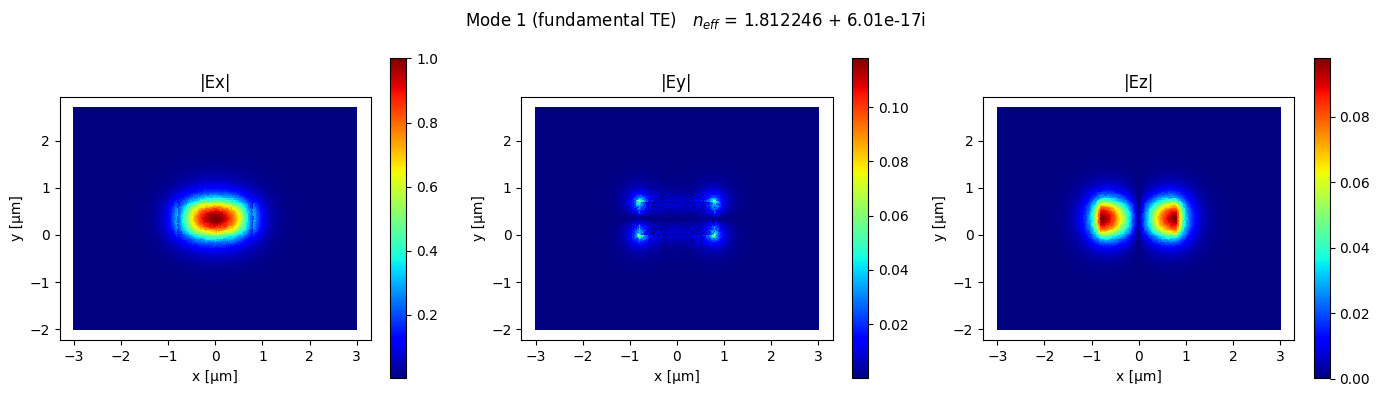

  Saved Mode_2.png


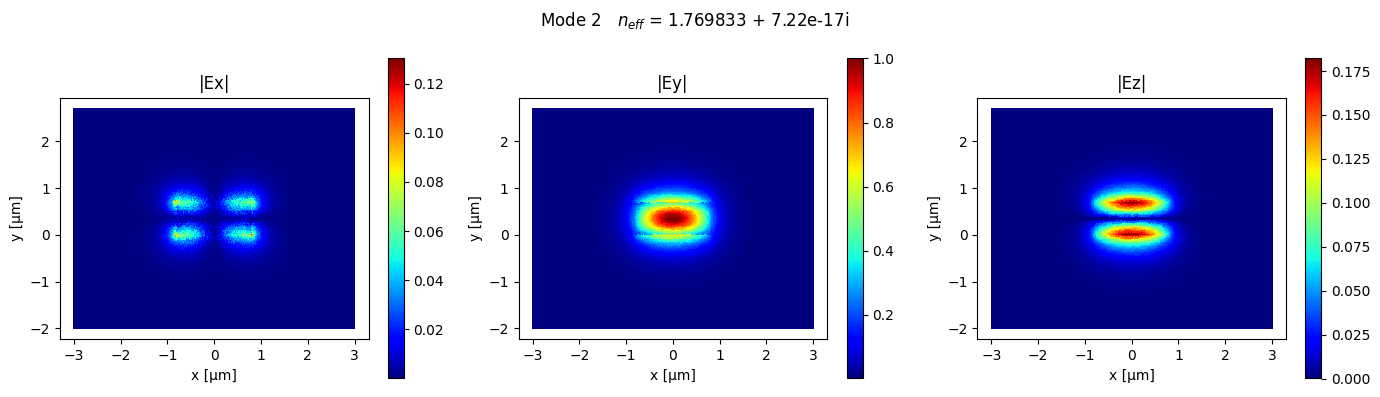

  Saved Mode_3.png


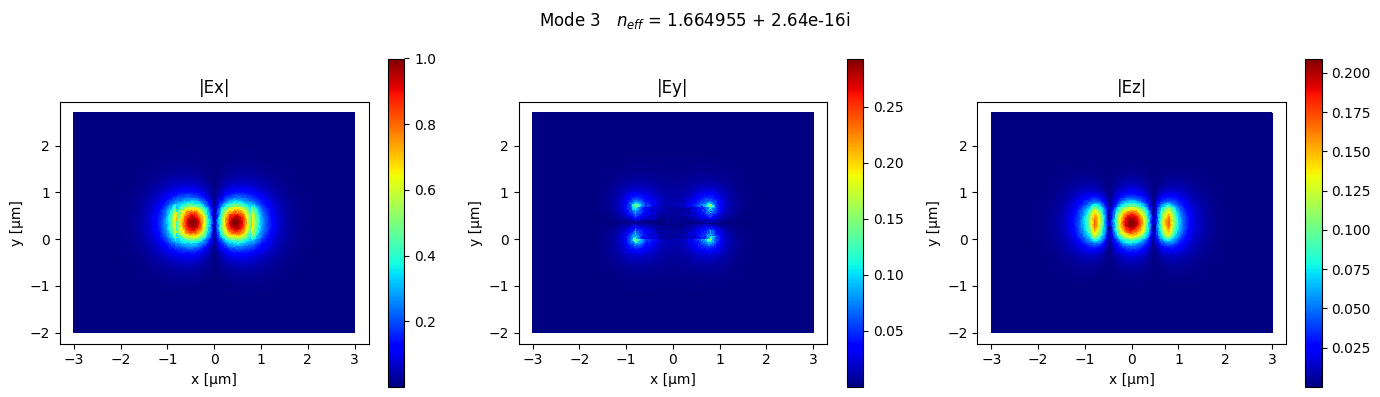

In [19]:
# =============================================================
#  TEST 1  (main script)
# =============================================================

def main():
    wavelength = 1.55   # µm

    # Geometry (µm)
    w_core = 1.6
    h_core = 0.7
    h_clad = 2.7
    h_box  = 2.00
    w_sim  = 6.00

    n_core = get_refractive_index('Si3N4', wavelength)
    n_clad = get_refractive_index('SiO2',  wavelength)
    n_box  = n_clad

    num_modes        = 6
    mesh_res         = round(w_sim / wavelength * 100)
    compute_overlaps = False
    plot_mesh        = False

    print(f"n_core (Si3N4) = {n_core:.6f}")
    print(f"n_clad (SiO2)  = {n_clad:.6f}")

    print("Building mesh ...")
    nodes, elems, epsilon_r, regions = build_soi_mesh(
        w_core, h_core, h_clad, h_box, w_sim,
        n_core, n_clad, n_box, mesh_res)
    print(f"Nodes: {nodes.shape[0]},  Elements: {elems.shape[0]}")

    # Optional: plot mesh
    if plot_mesh:
        fig, ax = plt.subplots(figsize=(8, 6))
        triang = mtri.Triangulation(nodes[:, 0], nodes[:, 1], elems)
        tc = ax.tripcolor(triang, facecolors=epsilon_r, cmap='viridis',
                          shading='flat', edgecolors='k', linewidth=0.1)
        fig.colorbar(tc, ax=ax, label='Relative Permittivity εr')
        ax.set_aspect('equal')
        ax.set_xlim(-w_core * 1.2, w_core * 1.2)
        ax.set_ylim(-h_core * 0.2, h_core * 1.2)
        ax.set_xlabel('x [µm]'); ax.set_ylabel('y [µm]')
        ax.set_title('Mesh Material Distribution (εr)')
        fig.savefig('figure_mesh.png', dpi=150)
        plt.show()

    print("Assembling & solving eigenvalue problem ...")
    t0 = time.perf_counter()
    modes = compute_modes(nodes, elems, epsilon_r, wavelength,
                          num_modes=num_modes, mu_r=1.0)
    print(f"Elapsed: {time.perf_counter() - t0:.2f} s")

    # ---- Print results ----
    print("\n--- Guided modes ---")
    for m_idx, mode in enumerate(modes):
        print(f"Mode {m_idx + 1}:  n_eff = {np.real(mode['n_eff']):.6f} + "
              f"{np.imag(mode['n_eff']):.2e}i,  TE-frac = {mode['te_fraction']:.3f}")

    # ---- Plot dominant modes ----
    plot_mode_fields(modes[0], nodes, elems, 'Mode 1 (fundamental TE)')
    plot_mode_fields(modes[1], nodes, elems, 'Mode 2')
    plot_mode_fields(modes[2], nodes, elems, 'Mode 3')

    # ---- Overlap matrix ----
    if compute_overlaps:
        print("\nComputing overlap matrix ...")
        N  = len(modes)
        OL = np.zeros((N, N), dtype=complex)
        for i in range(N):
            for j in range(N):
                OL[i, j] = calculate_overlap(modes[i], modes[j])

        fig, ax = plt.subplots()
        im = ax.imshow(np.real(OL), origin='upper', cmap='viridis')
        fig.colorbar(im, ax=ax)
        ax.set_title('Re{Overlap integrals}')
        ax.set_xlabel('Mode j'); ax.set_ylabel('Mode i')
        ax.set_xticks(range(N)); ax.set_yticks(range(N))
        ax.set_xticklabels(range(1, N + 1))
        ax.set_yticklabels(range(1, N + 1))
        plt.tight_layout()
        plt.show()


if __name__ == '__main__':
    main()